In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

houses = pd.read_csv('data/bygningsbestand_2022.csv').set_index('byggeaar')
houses

,antall,varmepumpe,etterisolert,energi
byggeaar,,,,
1900,79505.0,0.0,0.0,22480.199109
1901,2407.0,0.0,0.0,22480.199109
1902,2407.0,0.0,0.0,22480.199109
1903,2407.0,0.0,0.0,22480.199109
1904,2407.0,0.0,0.0,22480.199109
...,...,...,...,...
2018,7683.3,0.0,0.0,18766.975225
2019,7683.3,0.0,0.0,18766.975225
2020,7683.3,0.0,0.0,18766.975225


In [6]:
projection_years = np.arange(2022, 2101)
revet_per_aar    = 2000    # number of buildings demolished per year
demolition_rate =0.0011#1100/1e6 #about one million houses

# Carbon intensity (kgCO₂/kWh) — all electric
carbon_intensity = pd.Series(
    np.linspace(0.250, 0.050, len(projection_years)),
    index=projection_years,
)

# Retrofit scenario
retrofit_rate             = 0.01   # same rate for both heat pump and insulation
varmepumpe_per_ar         = 10000
isolering_per_ar          = 10000
retrofit_max_year         = 1989   # only upgrade houses built up to this year
andel_vp_2022             = 0.40   # share already with heat pump in 2022
andel_iso_2022            = 0.20   # share already insulated in 2022
varmepumpe_besparelse     = 0.50   # heat pump reduces heating energy by 50%
etterisolering_besparelse = 0.25   # insulation reduces heating energy by 25%
oppvarming_andel          = 0.67   # fraction of energy used for heating
co2_per_varmepumpe        = 7.87*1e3   # tCO₂ per heat pump
co2_per_etterisolering    = 0.56*1e3   # tCO₂ per insulation job

In [7]:
house_stock = pd.DataFrame(0.0,
                           index=houses.index,
                           columns = projection_years)

house_stock.loc[:,2022] = houses['antall']
heat_pump_adoption = pd.Series(0.0, index = projection_years)
heat_pump_andel = pd.Series(0.0, index = projection_years)

isolering_adoption = pd.Series(0.0, index = projection_years)
isolering_andel = pd.Series(0.0, index = projection_years)

for yr in projection_years[1:]:
    house_stock.loc[:,yr] = house_stock.loc[:,yr-1]*(1-demolition_rate) 

    heat_pump_adoption[yr] = heat_pump_adoption[yr-1]*(1-demolition_rate)+varmepumpe_per_ar
    heat_pump_andel[yr] = heat_pump_adoption[yr]/house_stock.loc[:,yr].sum()
  

    isolering_adoption[yr] = isolering_adoption[yr-1]*(1-demolition_rate)+isolering_per_ar
    isolering_andel[yr] = isolering_adoption[yr]/house_stock.loc[:,yr].sum()


heat_pump_andel

2022    0.000000
2023    0.007760
2024    0.015529
2025    0.023307
2026    0.031093
          ...   
2096    0.597978
2097    0.606397
2098    0.614826
2099    0.623263
2100    0.631710
Length: 79, dtype: float64

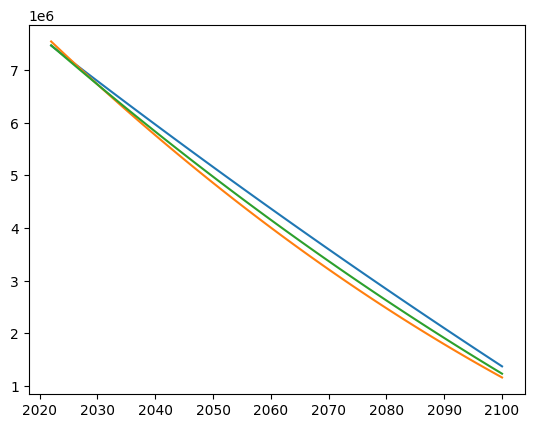

In [8]:
energy = pd.DataFrame(0.0, index=projection_years, columns=['base', 'heat_pump', 'insulation'])
emmison =  pd.DataFrame(0.9, index=projection_years, columns=['base', 'heat_pump', 'insulation'])
heat_pump_install_emmision = pd.Series(0.0, index = projection_years)
insulation_install_emmision = pd.Series(0.0, index = projection_years)

heat_pump_saving = varmepumpe_besparelse*oppvarming_andel
insulation_saving = etterisolering_besparelse*oppvarming_andel
for yr in projection_years:
    energy.loc[yr, 'base'] = house_stock.loc[:,yr]@houses['energi']
    emmison.loc[yr, 'base'] = energy.loc[yr, 'base']*carbon_intensity.loc[yr]
    
    energy.loc[yr, 'heat_pump'] = house_stock.loc[:,yr]@houses['energi']*(1-heat_pump_saving*heat_pump_andel[yr])
    heat_pump_install_emmision[yr] = varmepumpe_per_ar*co2_per_varmepumpe
    emmison.loc[yr, 'heat_pump'] = energy.loc[yr, 'heat_pump']*carbon_intensity.loc[yr] + heat_pump_install_emmision[yr]

    energy.loc[yr, 'insulation'] = house_stock.loc[:,yr]@houses['energi']*(1-insulation_saving*heat_pump_andel[yr])
    insulation_install_emmision[yr] = isolering_per_ar*co2_per_etterisolering
    emmison.loc[yr, 'insulation'] = energy.loc[yr, 'insulation']*carbon_intensity.loc[yr] + insulation_install_emmision[yr]
energy

plt.plot(projection_years, emmison['base']/1e3)
plt.plot(projection_years, emmison['heat_pump']/1e3)
plt.plot(projection_years, emmison['insulation']/1e3)

Spart med varmepumpe:     20,814,481 tonnCO₂
Spart med etterisolering: 13,073,491 tonnCO₂


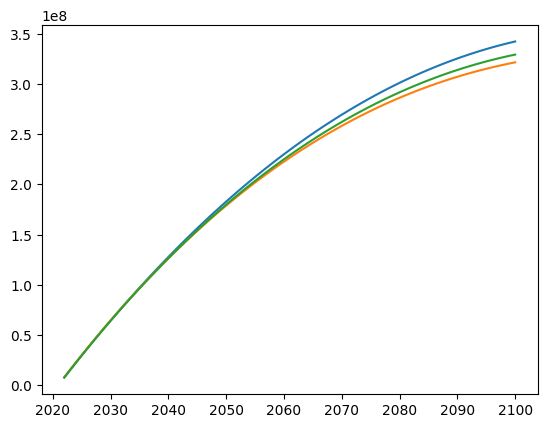

In [9]:
base_c = emmison['base'].cumsum()/1e3
heat_c = emmison['heat_pump'].cumsum()/1e3
iso_c = emmison['insulation'].cumsum()/1e3

plt.plot(projection_years, base_c)
plt.plot(projection_years, heat_c)
plt.plot(projection_years, iso_c)

print(f"Spart med varmepumpe:     {base_c.iloc[-1] - heat_c.iloc[-1]:,.0f} tonnCO₂")
print(f"Spart med etterisolering: {base_c.iloc[-1] - iso_c.iloc[-1]:,.0f} tonnCO₂")

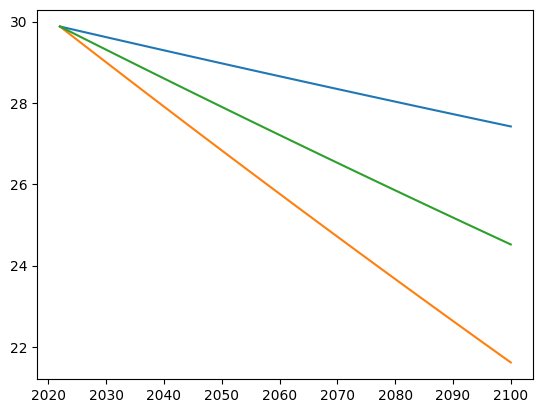

In [ ]:
plt.plot(projection_years, energy['base']/1e9)
plt.plot(projection_years, energy['heat_pump']/1e9)
plt.plot(projection_years, energy['insulation']/1e9)

Spart med varmepumpe:     232 TWh
Spart med etterisolering: 116 TWh


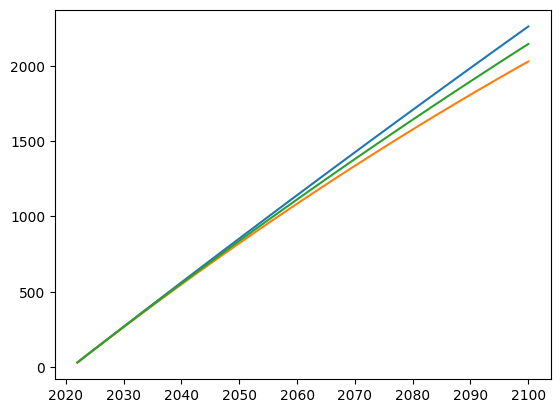

In [ ]:
base_ce = energy['base'].cumsum()/1e9
heat_ce = energy['heat_pump'].cumsum()/1e9
iso_ce = energy['insulation'].cumsum()/1e9

plt.plot(projection_years, base_ce)
plt.plot(projection_years, heat_ce)
plt.plot(projection_years, iso_ce)

print(f"Spart med varmepumpe:     {base_ce.iloc[-1] - heat_ce.iloc[-1]:,.0f} TWh")
print(f"Spart med etterisolering: {base_ce.iloc[-1] - iso_ce.iloc[-1]:,.0f} TWh")